# Análise do Yelp dataset

Notebook contendo uma análise geral dos dados do Yelp dataset.

## Bibliotecas

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter


In [12]:
path = "../data/processed/yelp/yelp.user"

## Estatísticas descritivas

Total users: 1,322,350

activity
Inactive         1,239,593 ( 93.74%)
Active              82,757 (  6.26%)



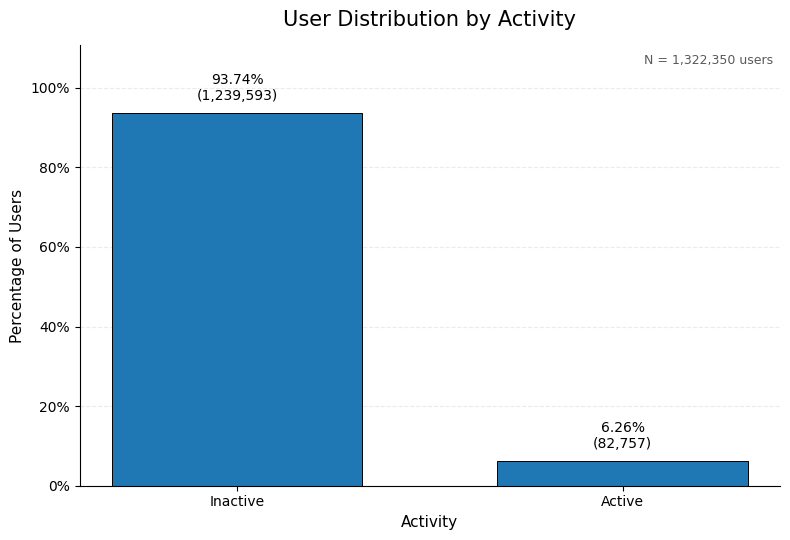

friend_count
No friends         541,196 ( 40.93%)
1–10               247,509 ( 18.72%)
11–100             316,085 ( 23.90%)
101+               217,560 ( 16.45%)



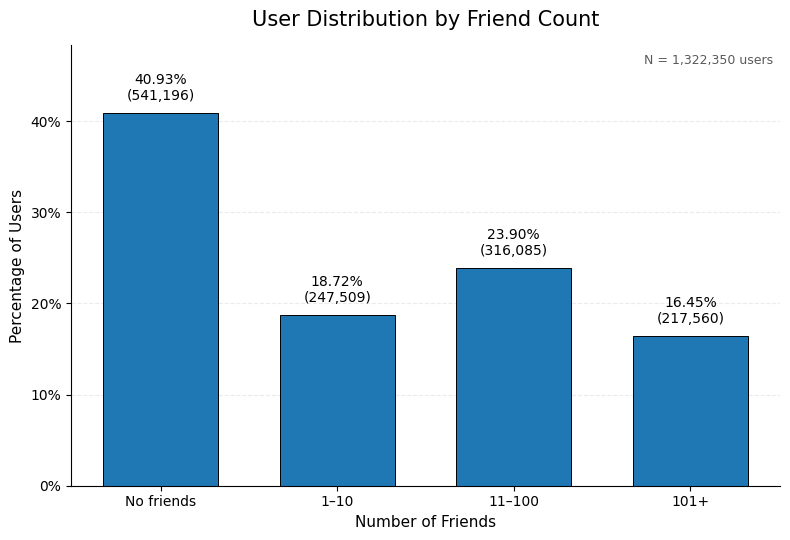

fans
No fans          1,013,732 ( 76.66%)
1 fan              143,012 ( 10.81%)
2–13               134,208 ( 10.15%)
14+                 31,398 (  2.37%)



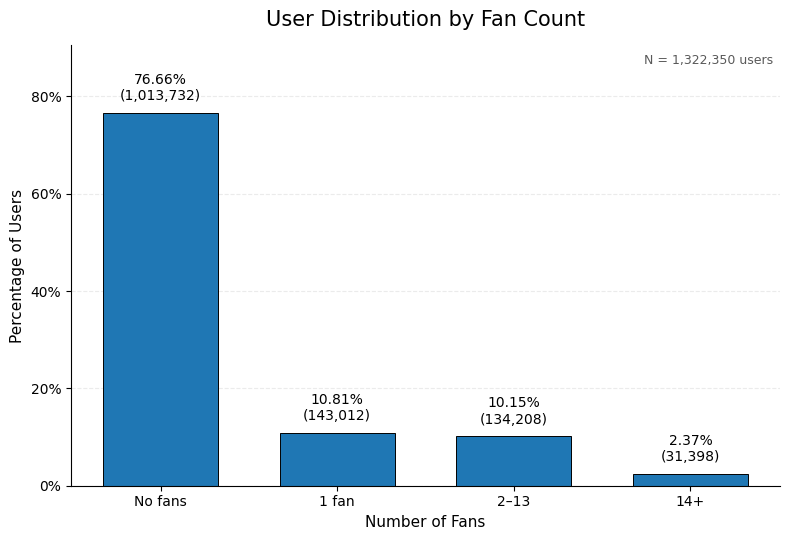

tenure
< 1 year            25,234 (  1.91%)
1–3 years           93,569 (  7.08%)
3–5 years          181,551 ( 13.73%)
5+ years         1,021,996 ( 77.29%)



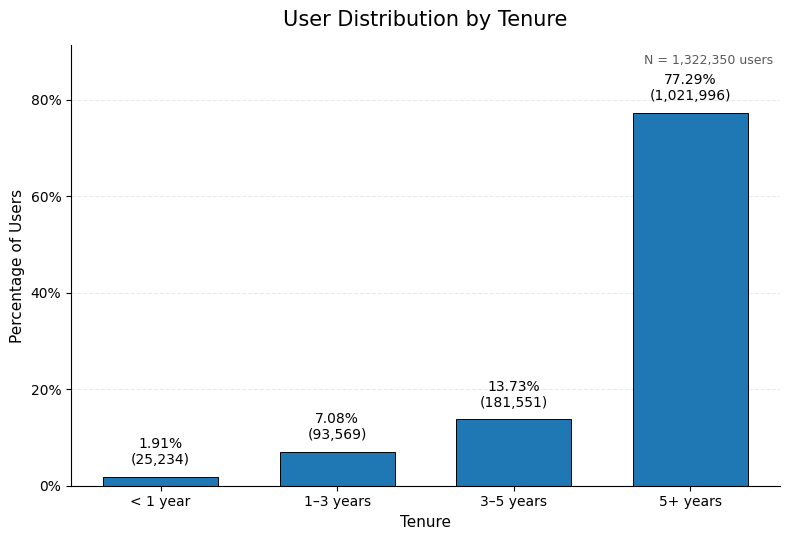

In [13]:
# ============================================================
# Group definitions
# ============================================================

def _friend_count_group(friend_count: float) -> str:
    if friend_count == 0:
        return "no_friends"

    if friend_count <= 10:
        return "1_10"

    if friend_count <= 100:
        return "11_100"

    return "101_plus"


def _fans_group(fans: float) -> str:
    if fans == 0:
        return "no_fans"

    if fans == 1:
        return "one_fan"

    if fans <= 13:
        return "2_13"

    return "14_plus"


def _tenure_group(tenure_years: float) -> str:
    if tenure_years < 1:
        return "under_1"

    if tenure_years < 3:
        return "1_3"

    if tenure_years < 5:
        return "3_5"

    return "5_plus"


# ============================================================
# Plot configuration
# ============================================================

GROUP_CONFIG = {
    "activity": {
        "column": "is_active",
        "order": [
            "inactive",
            "active",
        ],
        "labels": {
            "inactive": "Inactive",
            "active": "Active",
        },
        "title": "User Distribution by Activity",
        "xlabel": "Activity",
        "filename": "activity_distribution",
    },

    "friend_count": {
        "column": "friend_count_group",
        "order": [
            "no_friends",
            "1_10",
            "11_100",
            "101_plus",
        ],
        "labels": {
            "no_friends": "No friends",
            "1_10": "1–10",
            "11_100": "11–100",
            "101_plus": "101+",
        },
        "title": "User Distribution by Friend Count",
        "xlabel": "Number of Friends",
        "filename": "friend_count_distribution",
    },

    "fans": {
        "column": "fans_group",
        "order": [
            "no_fans",
            "one_fan",
            "2_13",
            "14_plus",
        ],
        "labels": {
            "no_fans": "No fans",
            "one_fan": "1 fan",
            "2_13": "2–13",
            "14_plus": "14+",
        },
        "title": "User Distribution by Fan Count",
        "xlabel": "Number of Fans",
        "filename": "fans_distribution",
    },

    "tenure": {
        "column": "tenure_group",
        "order": [
            "under_1",
            "1_3",
            "3_5",
            "5_plus",
        ],
        "labels": {
            "under_1": "< 1 year",
            "1_3": "1–3 years",
            "3_5": "3–5 years",
            "5_plus": "5+ years",
        },
        "title": "User Distribution by Tenure",
        "xlabel": "Tenure",
        "filename": "tenure_distribution",
    },
}


# ============================================================
# Data preparation
# ============================================================

def load_users(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path, sep="\t")

    # RecBole headers:
    # user_id:token -> user_id
    # fans:float    -> fans
    df.columns = [
        column.split(":")[0]
        for column in df.columns
    ]

    # Numeric columns
    numeric_columns = [
        "friend_count",
        "fans",
        "tenure_years",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    # Normalize activity.
    # Handles values such as true/false, True/False, 1/0.
    df["is_active"] = (
        df["is_active"]
        .astype(str)
        .str.lower()
        .map({
            "true": "active",
            "false": "inactive",
            "1": "active",
            "0": "inactive",
        })
    )

    # Create grouping columns
    df["friend_count_group"] = (
        df["friend_count"]
        .apply(_friend_count_group)
    )

    df["fans_group"] = (
        df["fans"]
        .apply(_fans_group)
    )

    df["tenure_group"] = (
        df["tenure_years"]
        .apply(_tenure_group)
    )

    return df


# ============================================================
# Plot
# ============================================================

def plot_group_distribution(
    df: pd.DataFrame,
    config: dict,
    output_dir: Path | None = None,
):
    column = config["column"]
    order = config["order"]
    labels = config["labels"]

    counts = (
        df[column]
        .value_counts()
        .reindex(order, fill_value=0)
    )

    total = counts.sum()

    percentages = counts / total * 100

    x_labels = [
        labels[group]
        for group in order
    ]

    fig, ax = plt.subplots(
        figsize=(8, 5.5)
    )

    bars = ax.bar(
        x_labels,
        percentages,
        width=0.65,
        edgecolor="black",
        linewidth=0.7,
    )

    # --------------------------------------------------------
    # Labels above bars
    # --------------------------------------------------------

    max_percentage = percentages.max()

    for bar, count, percentage in zip(
        bars,
        counts,
        percentages,
    ):
        ax.annotate(
            f"{percentage:.2f}%\n({count:,})",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
            ),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    # --------------------------------------------------------
    # Appearance
    # --------------------------------------------------------

    ax.set_title(
        config["title"],
        fontsize=15,
        pad=14,
    )

    ax.set_xlabel(
        config["xlabel"],
        fontsize=11,
    )

    ax.set_ylabel(
        "Percentage of Users",
        fontsize=11,
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(
            xmax=100,
            decimals=0,
        )
    )

    # Extra room for annotations
    ax.set_ylim(
        0,
        max_percentage * 1.18,
    )

    # Horizontal grid only
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25,
    )

    ax.set_axisbelow(True)

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Small dataset-size note
    ax.text(
        0.99,
        0.98,
        f"N = {total:,} users",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        alpha=0.65,
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    if output_dir is not None:
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        base_path = (
            output_dir
            / config["filename"]
        )

        # PNG for quick visualization
        fig.savefig(
            base_path.with_suffix(".png"),
            dpi=300,
            bbox_inches="tight",
        )

        # PDF for paper / LaTeX
        fig.savefig(
            base_path.with_suffix(".pdf"),
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)


# ============================================================
# Generate all plots
# ============================================================

def plot_all_user_metadata(
    file_path: str,
    output_dir: str = "plots/user_metadata",
):
    df = load_users(file_path)

    output_path = Path(output_dir)

    print(f"Total users: {len(df):,}")
    print()

    for metadata, config in GROUP_CONFIG.items():
        print("=" * 60)
        print(metadata)
        print("=" * 60)

        counts = (
            df[config["column"]]
            .value_counts()
            .reindex(
                config["order"],
                fill_value=0,
            )
        )

        percentages = counts / counts.sum() * 100

        for group in config["order"]:
            label = config["labels"][group]

            print(
                f"{label:<15} "
                f"{counts[group]:>10,} "
                f"({percentages[group]:>6.2f}%)"
            )

        print()

        plot_group_distribution(
            df=df,
            config=config,
            output_dir=output_path,
        )


# ============================================================
# Example
# ============================================================

plot_all_user_metadata(
    file_path=path,
    output_dir="plots/yelp/user_metadata",
)

## ECDF da quantidade de fans

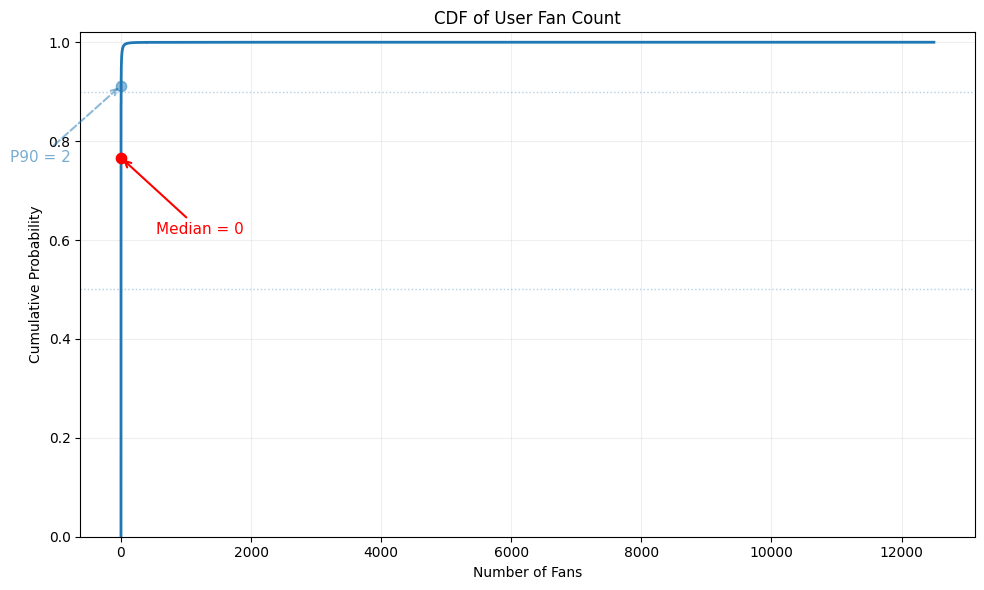

Number of users: 1,322,350
Minimum: 0
Median (P50): 0
P90: 2
Maximum: 12497


In [ ]:
def plot_fans_cdf(file_path: str):
    # Read RecBole-style TSV file
    df = pd.read_csv(file_path, sep="\t")

    # Remove RecBole type suffixes:
    # "user_id:token" -> "user_id"
    # "fans:float"    -> "fans"
    df.columns = [column.split(":")[0] for column in df.columns]

    # Remove missing values and guarantee numeric type
    fans = pd.to_numeric(df["fans"], errors="coerce").dropna()

    # Sort values for empirical CDF
    x = np.sort(fans.to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)

    # Use observed values as percentile thresholds.
    # This is useful because "fans" is a discrete variable.
    median = np.quantile(x, 0.50, method="higher")
    p90 = np.quantile(x, 0.90, method="higher")

    # Actual ECDF position of each threshold
    median_y = np.searchsorted(x, median, side="right") / len(x)
    p90_y = np.searchsorted(x, p90, side="right") / len(x)

    _, ax = plt.subplots(figsize=(10, 6))

    # CDF
    ax.plot(
        x,
        y,
        linewidth=2,
        label="CDF"
    )

    # -------------------------
    # Median
    # -------------------------
    ax.scatter(
        median,
        median_y,
        color="red",
        s=55,
        zorder=5
    )

    ax.annotate(
        f"Median = {median:.0f}",
        xy=(median, median_y),
        xytext=(25, -55),
        textcoords="offset points",
        color="red",
        fontsize=11,
        arrowprops={
            "arrowstyle": "->",
            "color": "red",
            "linewidth": 1.5
        }
    )

    # -------------------------
    # P90
    # -------------------------
    ax.scatter(
        p90,
        p90_y,
        color="tab:blue",
        alpha=0.5,
        s=55,
        zorder=5
    )

    ax.annotate(
        f"P90 = {p90:.0f}",
        xy=(p90, p90_y),
        xytext=(-80, -55),
        textcoords="offset points",
        color="tab:blue",
        alpha=0.6,
        fontsize=11,
        arrowprops={
            "arrowstyle": "->",
            "color": "tab:blue",
            "linestyle": "--",
            "linewidth": 1.5,
            "alpha": 0.5
        }
    )

    # Reference horizontal lines
    ax.axhline(
        0.50,
        linestyle=":",
        linewidth=1,
        alpha=0.35
    )

    ax.axhline(
        0.90,
        linestyle=":",
        linewidth=1,
        alpha=0.35
    )

    ax.set_xlabel("Number of Fans")
    ax.set_ylabel("Cumulative Probability")
    ax.set_title("CDF of User Fan Count")

    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    # Useful numerical information for the next iteration
    print(f"Number of users: {len(fans):,}")
    print(f"Minimum: {fans.min():.0f}")
    print(f"Median (P50): {median:.0f}")
    print(f"P90: {p90:.0f}")
    print(f"Maximum: {fans.max():.0f}")

# Example
plot_fans_cdf(path)

General information
-------------------------------------------------------
Total users:             1,322,350
Users with 0 fans:       1,013,732 (76.66%)
Users with > 0 fans:     308,618 (23.34%)

Distribution among users with fans
-------------------------------------------------------
fans =  1:  143,012 users ( 46.34%) | Cumulative:  46.34%
fans =  2:   49,735 users ( 16.12%) | Cumulative:  62.45%
fans =  3:   24,954 users (  8.09%) | Cumulative:  70.54%
fans =  4:   15,304 users (  4.96%) | Cumulative:  75.50%
fans =  5:   10,512 users (  3.41%) | Cumulative:  78.91%
fans =  6:    7,762 users (  2.52%) | Cumulative:  81.42%
fans =  7:    5,905 users (  1.91%) | Cumulative:  83.33%
fans =  8:    4,884 users (  1.58%) | Cumulative:  84.92%
fans =  9:    4,085 users (  1.32%) | Cumulative:  86.24%
fans = 10:    3,411 users (  1.11%) | Cumulative:  87.35%

Percentiles conditional on fans > 0
-------------------------------------------------------
P 25.0: 1
P 50.0: 2
P 75.0: 4
P 80.0: 

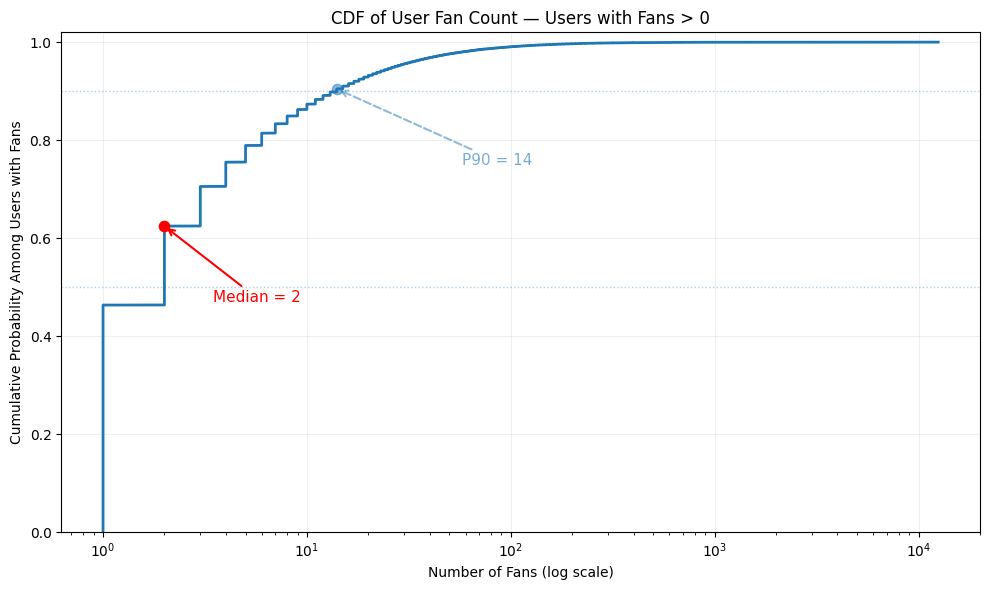

In [4]:
def analyze_positive_fans(file_path: str):
    df = pd.read_csv(file_path, sep="\t")

    # Remove RecBole type suffixes
    df.columns = [column.split(":")[0] for column in df.columns]

    fans = pd.to_numeric(df["fans"], errors="coerce").dropna()

    # --------------------------------------------------
    # Separate users with at least one fan
    # --------------------------------------------------
    positive_fans = fans[fans > 0]

    total_users = len(fans)
    positive_users = len(positive_fans)

    print("General information")
    print("-" * 55)
    print(f"Total users:             {total_users:,}")
    print(f"Users with 0 fans:       {(fans == 0).sum():,} ({(fans == 0).mean():.2%})")
    print(
        f"Users with > 0 fans:     "
        f"{positive_users:,} ({positive_users / total_users:.2%})"
    )

    # --------------------------------------------------
    # Exact distribution for small fan counts
    # --------------------------------------------------
    print()
    print("Distribution among users with fans")
    print("-" * 55)

    cumulative = 0

    for value in range(1, 11):
        count = (positive_fans == value).sum()
        percentage = count / positive_users
        cumulative += percentage

        print(
            f"fans = {value:>2}: "
            f"{count:>8,} users "
            f"({percentage:>7.2%}) | "
            f"Cumulative: {cumulative:>7.2%}"
        )

    # --------------------------------------------------
    # Conditional percentiles
    # --------------------------------------------------
    print()
    print("Percentiles conditional on fans > 0")
    print("-" * 55)

    percentiles = [
        0.25,
        0.50,
        0.75,
        0.80,
        0.90,
        0.95,
        0.975,
        0.99,
        0.995,
        0.999,
    ]

    percentile_values = {}

    for p in percentiles:
        value = np.quantile(
            positive_fans,
            p,
            method="higher"
        )

        percentile_values[p] = value

        print(
            f"P{p * 100:>5.1f}: {value:,.0f}"
        )

    print()
    print(f"Mean:    {positive_fans.mean():,.2f}")
    print(f"Maximum: {positive_fans.max():,.0f}")

    # --------------------------------------------------
    # ECDF
    # --------------------------------------------------
    x = np.sort(positive_fans.to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)

    median = percentile_values[0.50]
    p90 = percentile_values[0.90]

    median_y = (
        np.searchsorted(x, median, side="right")
        / len(x)
    )

    p90_y = (
        np.searchsorted(x, p90, side="right")
        / len(x)
    )

    _, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        x,
        y,
        linewidth=2
    )

    # Log scale is appropriate because fans > 0
    ax.set_xscale("log")

    # --------------------------------------------------
    # Median
    # --------------------------------------------------
    ax.scatter(
        median,
        median_y,
        color="red",
        s=55,
        zorder=5
    )

    ax.annotate(
        f"Median = {median:.0f}",
        xy=(median, median_y),
        xytext=(35, -55),
        textcoords="offset points",
        color="red",
        fontsize=11,
        arrowprops={
            "arrowstyle": "->",
            "color": "red",
            "linewidth": 1.5
        }
    )

    # --------------------------------------------------
    # P90
    # --------------------------------------------------
    ax.scatter(
        p90,
        p90_y,
        color="tab:blue",
        alpha=0.5,
        s=55,
        zorder=5
    )

    ax.annotate(
        f"P90 = {p90:.0f}",
        xy=(p90, p90_y),
        xytext=(90, -55),
        textcoords="offset points",
        color="tab:blue",
        alpha=0.6,
        fontsize=11,
        arrowprops={
            "arrowstyle": "->",
            "color": "tab:blue",
            "linestyle": "--",
            "linewidth": 1.5,
            "alpha": 0.5
        }
    )

    # Reference lines
    ax.axhline(
        0.50,
        linestyle=":",
        linewidth=1,
        alpha=0.35
    )

    ax.axhline(
        0.90,
        linestyle=":",
        linewidth=1,
        alpha=0.35
    )

    ax.set_xlabel("Number of Fans (log scale)")
    ax.set_ylabel(
        "Cumulative Probability Among Users with Fans"
    )

    ax.set_title(
        "CDF of User Fan Count — Users with Fans > 0"
    )

    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


analyze_positive_fans(path)

Conditional percentiles (fans > 0)
------------------------------------------------------------
P 90.0 =     14 fans | users >= threshold:   31,398 |  10.17% of positive |   2.37% of total
P 95.0 =     27 fans | users >= threshold:   15,904 |   5.15% of positive |   1.20% of total
P 97.5 =     49 fans | users >= threshold:    7,739 |   2.51% of positive |   0.59% of total
P 99.0 =     97 fans | users >= threshold:    3,108 |   1.01% of positive |   0.24% of total
P 99.5 =    155 fans | users >= threshold:    1,550 |   0.50% of positive |   0.12% of total
P 99.9 =    425 fans | users >= threshold:      311 |   0.10% of positive |   0.02% of total


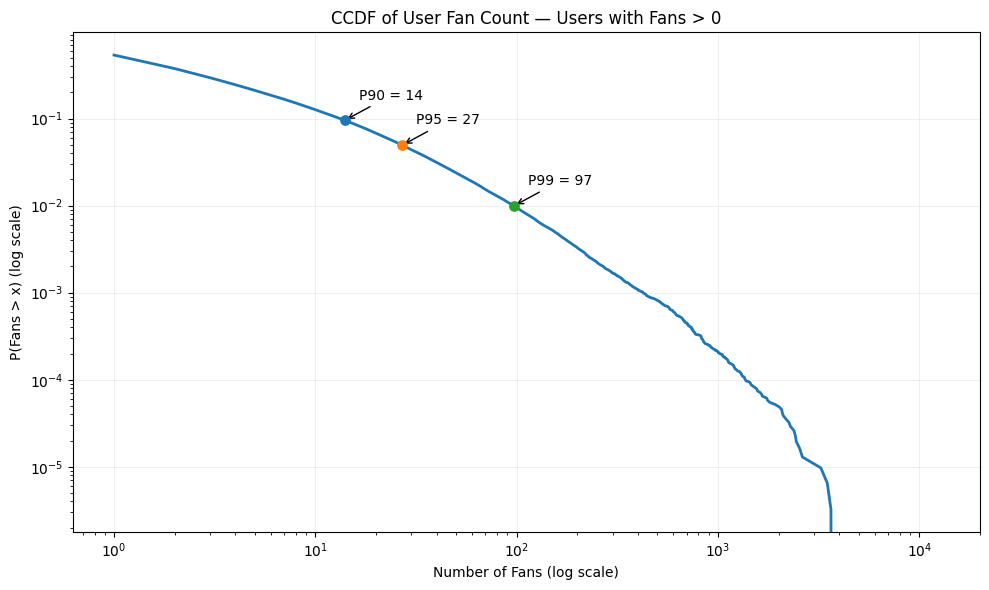

In [6]:
def analyze_fans_tail(file_path: str):
    df = pd.read_csv(file_path, sep="\t")
    df.columns = [column.split(":")[0] for column in df.columns]

    fans = pd.to_numeric(
        df["fans"],
        errors="coerce"
    ).dropna()

    positive = fans[fans > 0]

    # --------------------------------------------------
    # Percentiles
    # --------------------------------------------------
    percentiles = [
        0.90,
        0.95,
        0.975,
        0.99,
        0.995,
        0.999,
    ]

    print("Conditional percentiles (fans > 0)")
    print("-" * 60)

    thresholds = {}

    for p in percentiles:
        threshold = np.quantile(
            positive,
            p,
            method="higher"
        )

        thresholds[p] = threshold

        positive_count = (positive >= threshold).sum()
        total_count = (fans >= threshold).sum()

        print(
            f"P{p * 100:>5.1f} = {threshold:>6,.0f} fans | "
            f"users >= threshold: {positive_count:>8,} | "
            f"{positive_count / len(positive):>7.2%} of positive | "
            f"{total_count / len(fans):>7.2%} of total"
        )

    # --------------------------------------------------
    # CCDF
    # --------------------------------------------------
    values, counts = np.unique(
        positive.to_numpy(),
        return_counts=True
    )

    cumulative_counts = np.cumsum(counts)

    # P(X > x)
    ccdf = 1 - cumulative_counts / len(positive)

    _, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        values,
        ccdf,
        linewidth=2
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    # Mark P90, P95 and P99
    selected = {
        "P90": thresholds[0.90],
        "P95": thresholds[0.95],
        "P99": thresholds[0.99],
    }

    for label, threshold in selected.items():
        tail_probability = (
            (positive > threshold).sum()
            / len(positive)
        )

        ax.scatter(
            threshold,
            tail_probability,
            s=45,
            zorder=5
        )

        ax.annotate(
            f"{label} = {threshold:.0f}",
            xy=(threshold, tail_probability),
            xytext=(10, 15),
            textcoords="offset points",
            fontsize=10,
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1
            }
        )

    ax.set_xlabel("Number of Fans (log scale)")
    ax.set_ylabel("P(Fans > x) (log scale)")
    ax.set_title(
        "CCDF of User Fan Count — Users with Fans > 0"
    )

    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


analyze_fans_tail(path)